In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [2]:
df = pd.read_csv('spatial_data.csv')

In [3]:
df.head()

,X_Coordinate,Y_Coordinate
0,29.970162,62.959614
1,34.361253,13.617757
2,41.767192,59.666767
3,42.702611,67.590818
4,59.964128,55.983022


In [4]:
df.shape

(5500, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   X_Coordinate  5400 non-null   float64
 1   Y_Coordinate  5500 non-null   float64
dtypes: float64(2)
memory usage: 86.1 KB


In [6]:
df.describe()

,X_Coordinate,Y_Coordinate
count,5400.000000,5500.000000
mean,49.995488,49.215061
std,15.012663,17.387904
min,-7.845630,-100.000000
25%,39.616153,39.404794
50%,49.982779,49.931958
75%,60.363536,59.834591
max,109.134965,98.230613


In [7]:
df.isnull().sum()

X_Coordinate    100
Y_Coordinate      0
dtype: int64

In [8]:
df["X_Coordinate"] = df["X_Coordinate"].fillna(
    df["X_Coordinate"].mean()
)

df.isnull().sum()

X_Coordinate    0
Y_Coordinate    0
dtype: int64

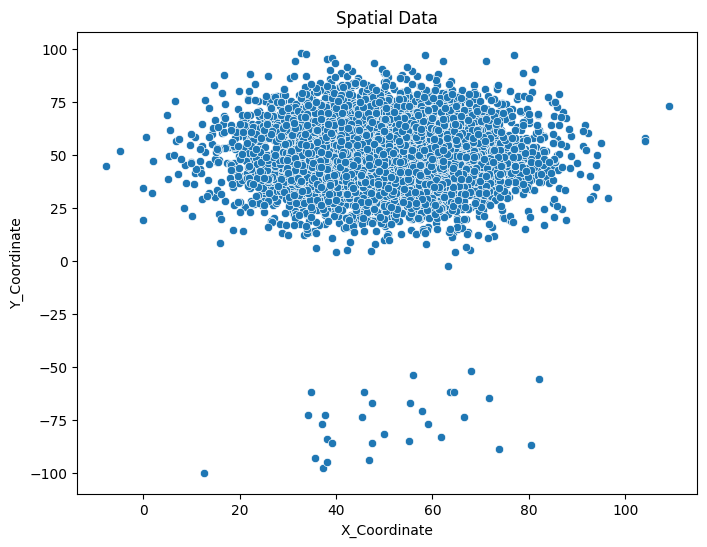

In [9]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="X_Coordinate",
    y="Y_Coordinate",
    data=df
)

plt.title("Spatial Data")
plt.show()

In [10]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

In [11]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

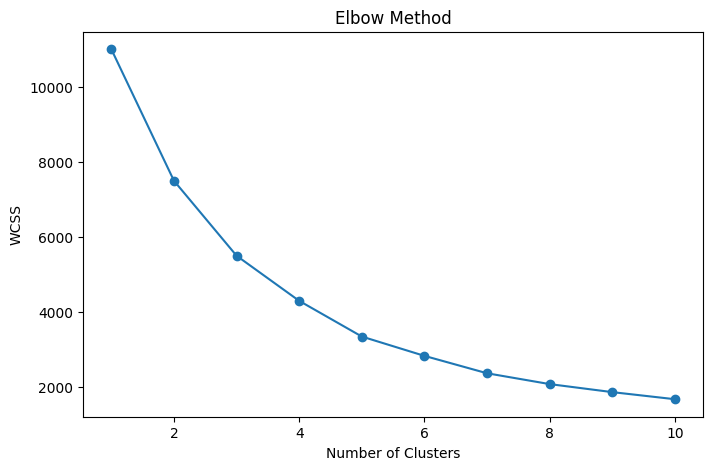

In [12]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [13]:
scores = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    scores.append(score)

    print(f"k = {k} --> Silhouette Score = {score:.4f}")

k = 2 --> Silhouette Score = 0.3222
k = 3 --> Silhouette Score = 0.3300
k = 4 --> Silhouette Score = 0.3344
k = 5 --> Silhouette Score = 0.3279
k = 6 --> Silhouette Score = 0.3142
k = 7 --> Silhouette Score = 0.3287
k = 8 --> Silhouette Score = 0.3246
k = 9 --> Silhouette Score = 0.3199
k = 10 --> Silhouette Score = 0.3222


In [14]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

In [15]:
df.head()

,X_Coordinate,Y_Coordinate,Cluster
0,29.970162,62.959614,3
1,34.361253,13.617757,0
2,41.767192,59.666767,3
3,42.702611,67.590818,3
4,59.964128,55.983022,1


In [16]:
score = silhouette_score(X_scaled, clusters)

print("Silhouette Score :", score)

Silhouette Score : 0.3343661305109066


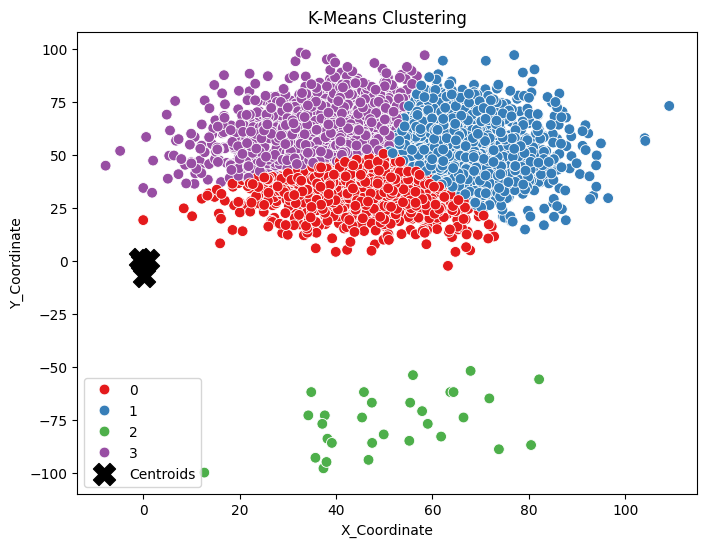

In [17]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="X_Coordinate",
    y="Y_Coordinate",
    hue="Cluster",
    palette="Set1",
    data=df,
    s=60
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    c='black',
    s=250,
    marker='X',
    label='Centroids'
)

plt.title("K-Means Clustering")

plt.legend()

plt.show()

In [18]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1","PC2"])

pca_df["Cluster"] = clusters

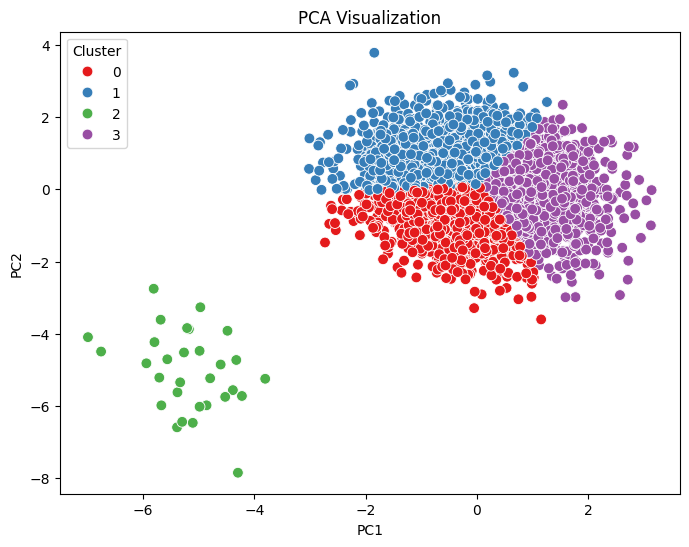

In [19]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    data=pca_df,
    s=60
)

plt.title("PCA Visualization")

plt.show()